In [236]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [237]:
house_prices = pd.read_csv('../datasets/house_prices_cleaned.zip')
house_copy = house_prices.copy()
house_copy.drop('Unnamed: 0', axis= 'columns', inplace= True)

C:\Users\HP\AppData\Local\Temp\ipykernel_15084\1314455057.py:1: DtypeWarning: Columns (0: locality) have mixed types. Specify dtype option on import or set low_memory=False.
  house_prices = pd.read_csv('../datasets/house_prices_cleaned.zip')


In [238]:
house_copy.describe()

,amount,price,carpet_area,bathroom,balcony,car_parking,super_area,bedrooms,total_floors
count,67841.000000,6.357500e+04,3.807500e+04,67721.000000,49133.000000,28863.000000,6.375800e+04,67831.000000,65529.000000
mean,107.353995,6.669812e+03,3.052560e+03,2.411187,2.087049,4.024045,3.215058e+03,2.543483,8.521281
std,687.905116,4.410867e+04,3.349072e+05,0.899991,1.019998,34.227493,2.399354e+05,0.831290,6.964287
min,1.000000,0.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000
25%,40.000000,3.765000e+03,8.010000e+02,2.000000,1.000000,1.000000,9.950249e+02,2.000000,4.000000
50%,64.000000,5.000000e+03,1.100000e+03,2.000000,2.000000,1.000000,1.287895e+03,3.000000,5.000000
75%,106.000000,7.034000e+03,1.476000e+03,3.000000,3.000000,1.000000,1.730000e+03,3.000000,12.000000
max,140030.000000,6.700000e+06,6.534000e+07,11.000000,11.000000,999.000000,4.347288e+07,10.000000,200.000000


# Univariate Analysis

In [239]:
def pie(df, explode, colors, edgecolor, textcolor):
    wedges, texts, autotexts = plt.pie(x= df.values, labels= df.index, explode= explode, autopct= '%0.1f%%', colors= colors, shadow= True)
    for wedge in wedges:
        wedge.set_edgecolor(edgecolor)

    for text in texts:
        text.set_fontweight('bold')

    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_color(textcolor)

In [240]:
def uni_box(y):
    sns.catplot(data= house_copy, y= y, kind= 'box')

In [241]:
def uni_hist(x, color):
    sns.displot(data= house_copy, x= x, kind= 'hist', kde= True, color= color)
    plt.xlim(house_copy[x].quantile(0.01), house_copy[x].quantile(0.99))

In [242]:
def bar_h(df, y, threshold, palette, edgecolor, linewidth):
    df = df[df['count'] >= threshold]
    sns.barplot(data= df, x= 'count', y= y, hue= y, palette= palette, edgecolor= edgecolor, linewidth= linewidth)

In [243]:
def bar_v(df, palette, edgecolor, linewidth):
    sns.catplot(x= df.index, y= df.values, kind= 'bar', palette= palette, edgecolor= edgecolor, linewidth= linewidth)

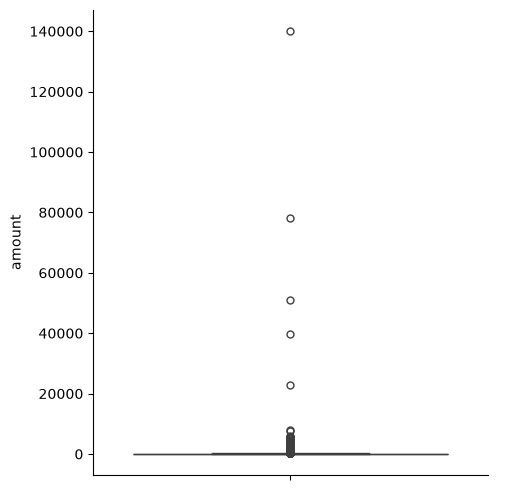

In [244]:
uni_box('amount')

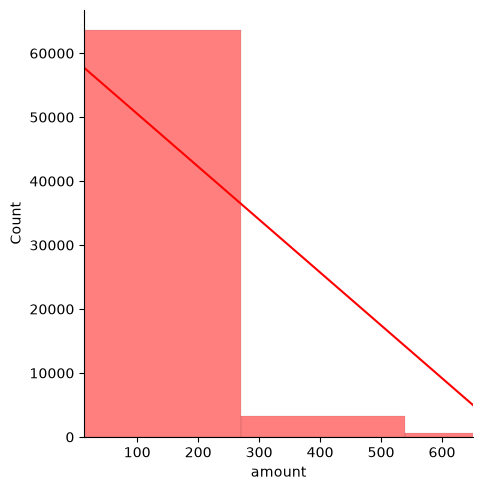

In [245]:
uni_hist('amount', 'red')

In [246]:
house_copy['amount'].skew()

np.float64(154.94097382310096)

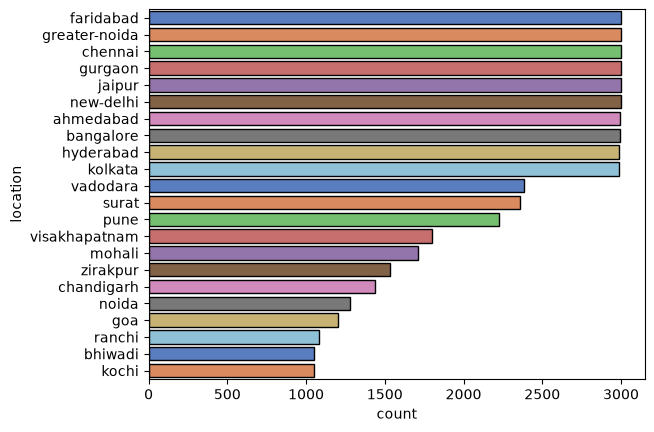

In [247]:
location_count = house_copy['location'].value_counts().reset_index()
bar_h(location_count, 'location', 1000, 'muted', 'black', 1)

In [248]:
location_count[location_count['count'] >= 1000]['count'].sum() / len(house_copy)

np.float64(0.7194832238385734)

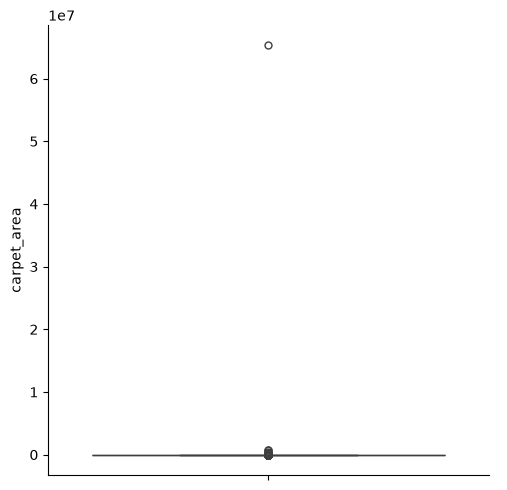

In [249]:
uni_box('carpet_area')

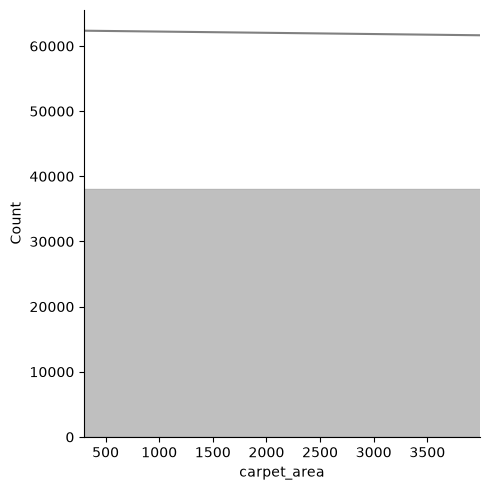

In [250]:
uni_hist('carpet_area', 'grey')

In [251]:
house_copy['carpet_area'].skew()

np.float64(195.0287137011458)

C:\Users\HP\AppData\Local\Temp\ipykernel_15084\2590324310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x= df.index, y= df.values, kind= 'bar', palette= palette, edgecolor= edgecolor, linewidth= linewidth)


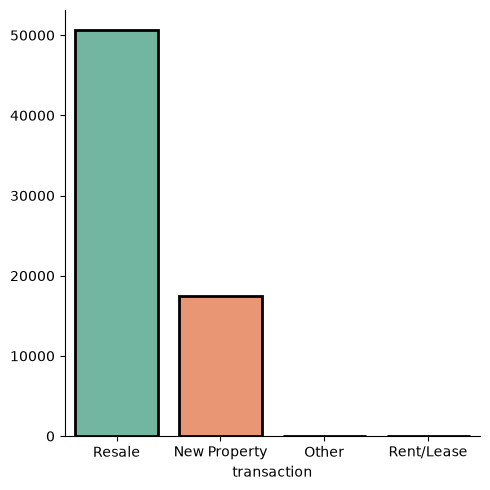

In [252]:
transaction_count = house_copy['transaction'].value_counts()
bar_v(transaction_count, 'Set2', 'black', 2)

In [253]:
transaction_count = transaction_count.reset_index()
transaction_count['percent'] = (transaction_count['count'] / sum(transaction_count['count'])) * 100
transaction_count

,transaction,count,percent
0,Resale,50614,74.307778
1,New Property,17438,25.601198
2,Other,60,0.088088
3,Rent/Lease,2,0.002936


In [254]:
house_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 68192 entries, 0 to 68191
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               68192 non-null  str    
 1   description         65974 non-null  str    
 2   amount              67841 non-null  float64
 3   price               63575 non-null  float64
 4   location            68192 non-null  str    
 5   carpet_area         38075 non-null  float64
 6   floor               65577 non-null  str    
 7   transaction         68114 non-null  str    
 8   furnishing          68192 non-null  str    
 9   facing              41392 non-null  str    
 10  overlooking         38657 non-null  str    
 11  society             29372 non-null  str    
 12  bathroom            67721 non-null  float64
 13  balcony             49133 non-null  float64
 14  car_parking         28863 non-null  float64
 15  ownership           43264 non-null  str    
 16  super_area     

C:\Users\HP\AppData\Local\Temp\ipykernel_15084\2590324310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x= df.index, y= df.values, kind= 'bar', palette= palette, edgecolor= edgecolor, linewidth= linewidth)


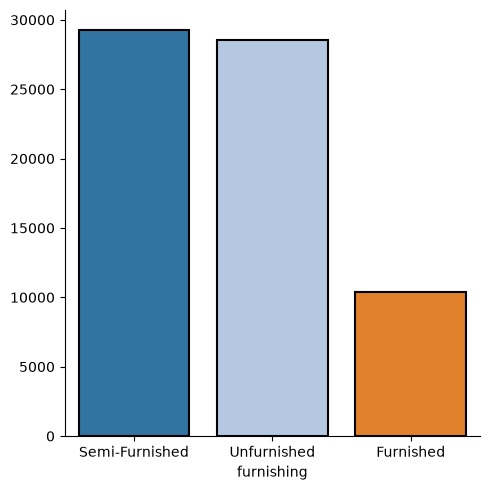

In [255]:
furnish_count = house_copy['furnishing'].value_counts()
bar_v(furnish_count, 'tab20', 'black', 1.5)

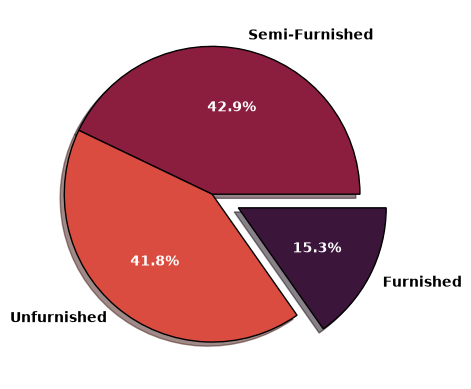

In [256]:
pie(furnish_count, [0, 0, 0.2], ['#8b1e3f', '#db4c40', '#3c153b'], 'black', 'white')



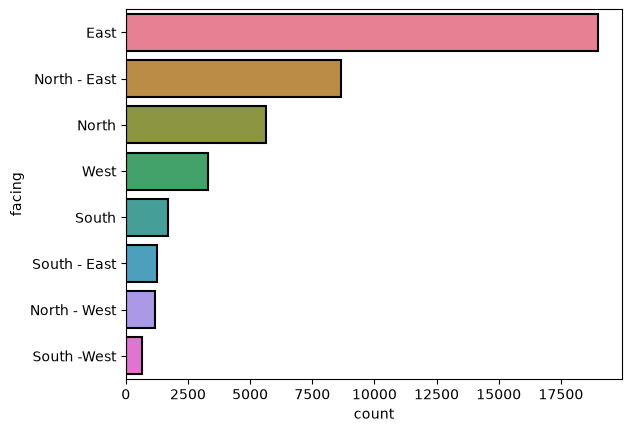

In [257]:
facing_count = house_copy['facing'].value_counts().reset_index()
bar_h(facing_count, 'facing', 0, 'husl', 'black', 1.5)

In [258]:
facing_count['percentage'] = (facing_count['count'] / len(house_copy)) * 100
nulls = (house_copy['facing'].isna().sum()) / len(house_copy) * 100
sums = facing_count['percentage'].sum()

In [259]:
print(nulls, sums)
mask = facing_count.head(1)
print((mask['percentage'].sum() / sums) * 100)

39.30079774753637 60.69920225246363
45.90258987243912


In [260]:
facing_count

,facing,count,percentage
0,East,19000,27.862506
1,North - East,8644,12.675974
2,North,5642,8.273698
3,West,3301,4.840744
4,South,1689,2.476830
5,South - East,1256,1.841858
6,North - West,1189,1.743606
7,South -West,671,0.983986


In [261]:
house_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 68192 entries, 0 to 68191
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               68192 non-null  str    
 1   description         65974 non-null  str    
 2   amount              67841 non-null  float64
 3   price               63575 non-null  float64
 4   location            68192 non-null  str    
 5   carpet_area         38075 non-null  float64
 6   floor               65577 non-null  str    
 7   transaction         68114 non-null  str    
 8   furnishing          68192 non-null  str    
 9   facing              41392 non-null  str    
 10  overlooking         38657 non-null  str    
 11  society             29372 non-null  str    
 12  bathroom            67721 non-null  float64
 13  balcony             49133 non-null  float64
 14  car_parking         28863 non-null  float64
 15  ownership           43264 non-null  str    
 16  super_area     

In [262]:
overlooking_count = house_copy['overlooking'].value_counts().reset_index()
overlooking_count

,overlooking,count
0,Main Road,12249
1,"Garden/Park,Main Road",9226
2,Garden/Park,8270
3,"Garden/Park,Main Road,Pool",6593
4,"Garden/Park,Pool",1750
5,Pool,355
6,"Main Road,Pool",214


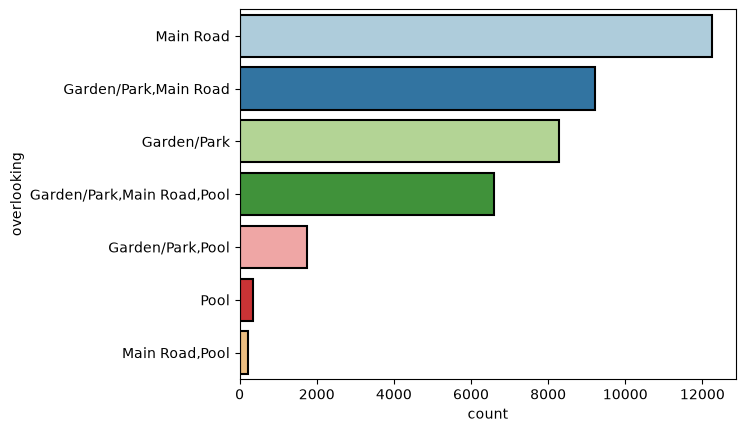

In [263]:
bar_h(overlooking_count, 'overlooking', 0, 'Paired', 'black', 1.5)

In [264]:
(house_copy['overlooking'].isna().sum() / len(house_copy)) * 100

np.float64(43.31153214453308)

In [265]:
(overlooking_count.loc[3, 'count'] / len(house_copy)) * 100

np.float64(9.668289535429375)

In [266]:
garden_park = (house_copy['overlooking'].str.contains('Garden/Park').sum() / len(house_copy)) * 100
main_road = (house_copy['overlooking'].str.contains('Main Road').sum() / len(house_copy)) * 100
pool = (house_copy['overlooking'].str.contains('Pool').sum() / len(house_copy)) * 100
print(garden_park, main_road, pool)

37.89154152979822 41.47407320506804 13.06898169873299


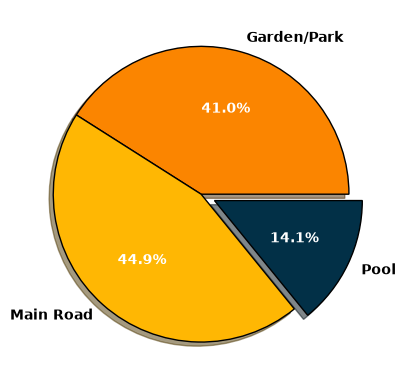

In [267]:
overlooking_df = pd.Series([garden_park, main_road, pool], index= ['Garden/Park', 'Main Road', 'Pool'])
pie(overlooking_df, [0, 0, 0.1], ['#fb8500', '#ffb703', '#023047'], 'black', 'white')